In [1]:
pip install numpy pandas matplotlib scikit-learn xgboost


Loading discharge data: B0005

Loading discharge data: B0006

Loading discharge data: B0018

DISCHARGE DATA
Training rows: 336
Test rows: 132

SOH MODEL COMPARISON

Training Linear Regression...

Training Random Forest...

Training SVR...

Training XGBoost...

Training MLP Neural Network...

FINAL MODEL COMPARISON
             Model  MAE (%)  RMSE (%)       R2
 Linear Regression 1.099899  1.303697 0.971444
               SVR 1.506880  1.975611 0.934423
           XGBoost 2.259917  2.648552 0.882141
     Random Forest 2.378229  2.901955 0.858509
MLP Neural Network 4.122548  5.471866 0.496943

BEST MODEL
Model: Linear Regression
MAE: 1.1 %
RMSE: 1.304 %
R²: 0.9714


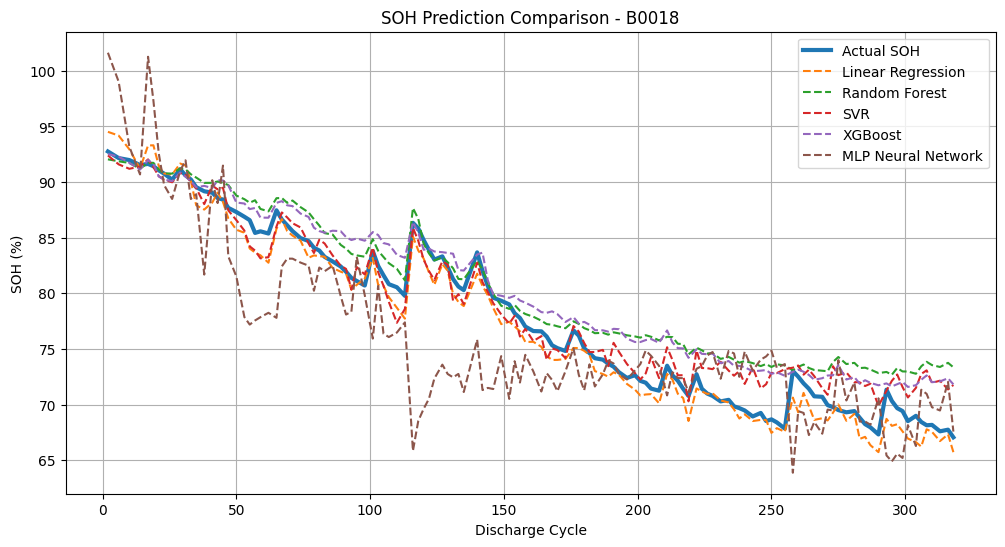

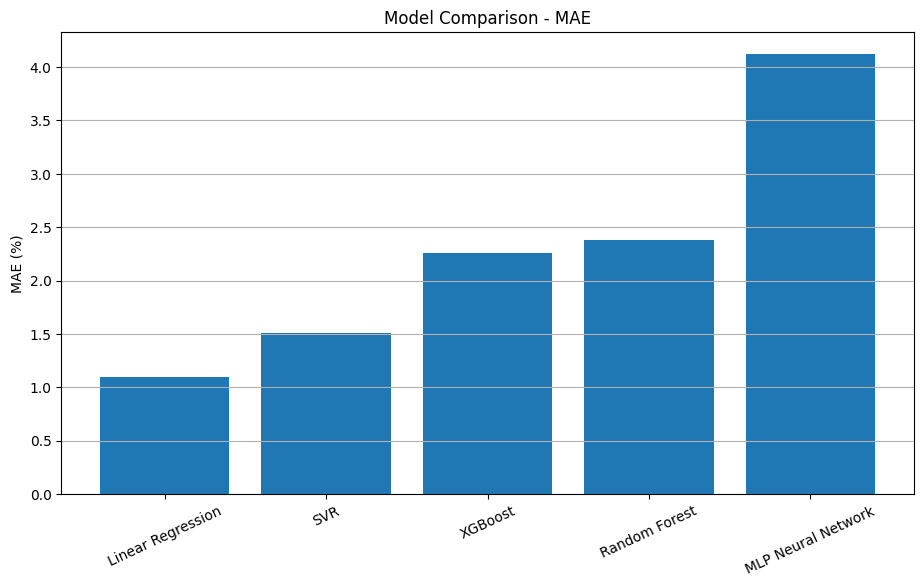

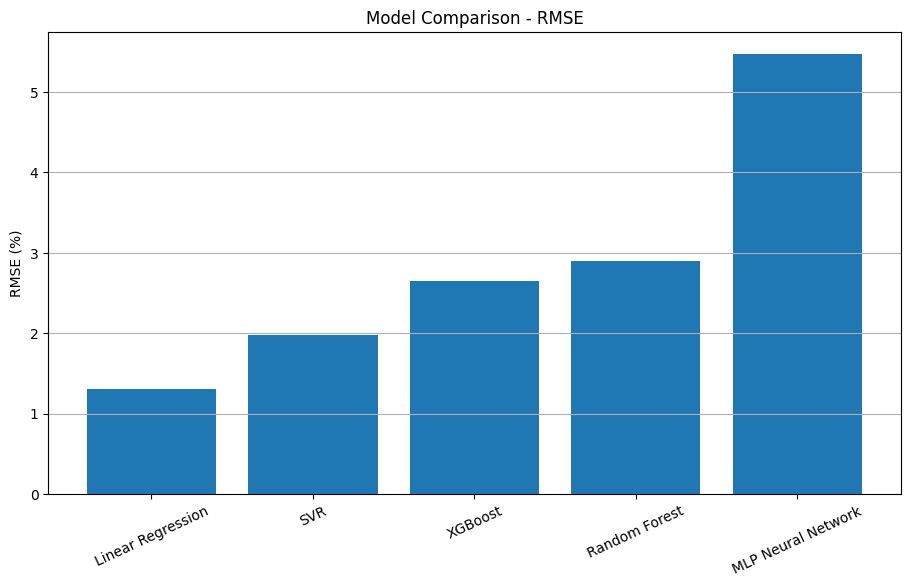

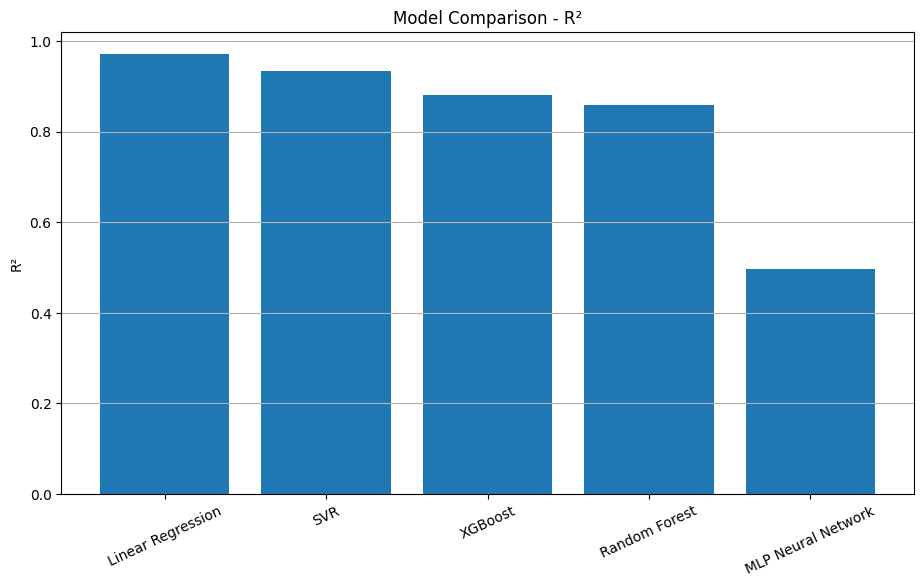

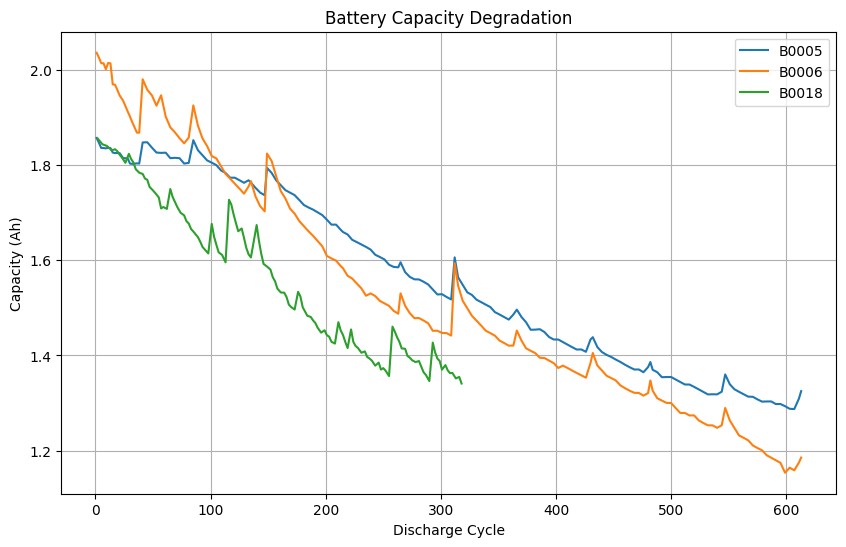

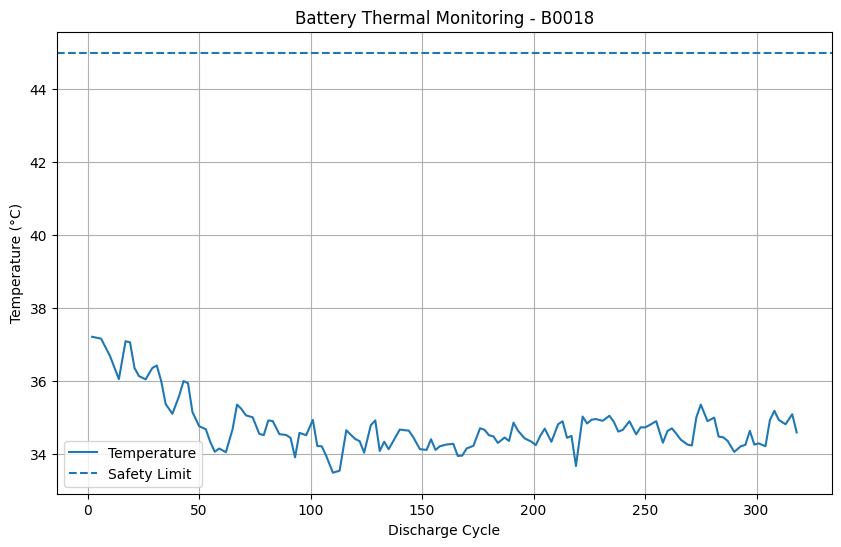

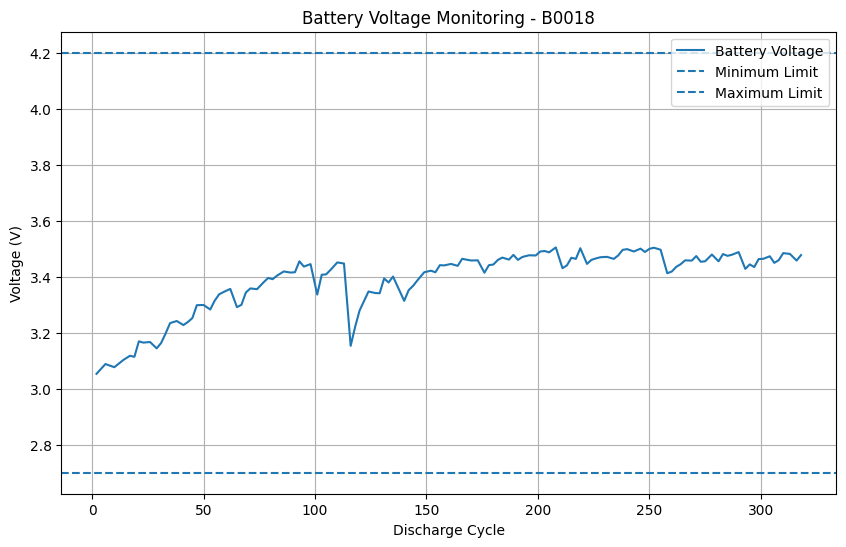


AVAILABLE CHARGE CYCLES
Number of charge cycles: 134
First cycle: 0
Last cycle: 317
Selected cycles: [np.int64(0), np.int64(126), np.int64(190), np.int64(253), np.int64(317)]


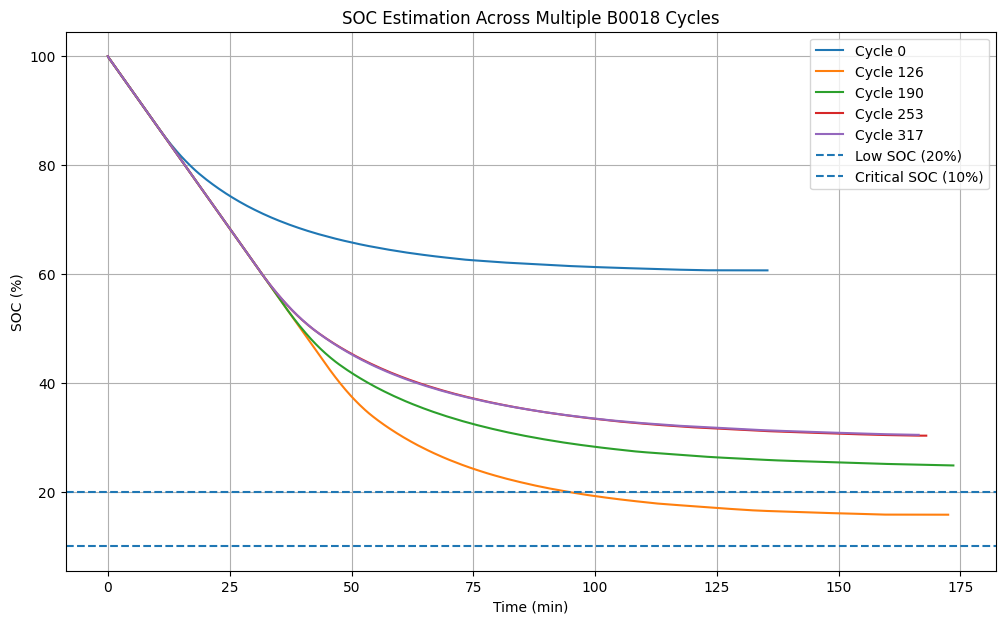


SOC SUMMARY
Cycle 0: Initial SOC = 100.00% | Final SOC = 60.67%
Cycle 126: Initial SOC = 100.00% | Final SOC = 15.79%
Cycle 190: Initial SOC = 100.00% | Final SOC = 24.84%
Cycle 253: Initial SOC = 100.00% | Final SOC = 30.31%
Cycle 317: Initial SOC = 100.00% | Final SOC = 30.46%

BMS STATUS SUMMARY
BMS_Status
NORMAL          1161
OVER VOLTAGE     238
Name: count, dtype: int64

Loading charge data: B0018

CHARGE PROFILE
Battery: B0018
Charge cycle: 0
Measurements: 2816


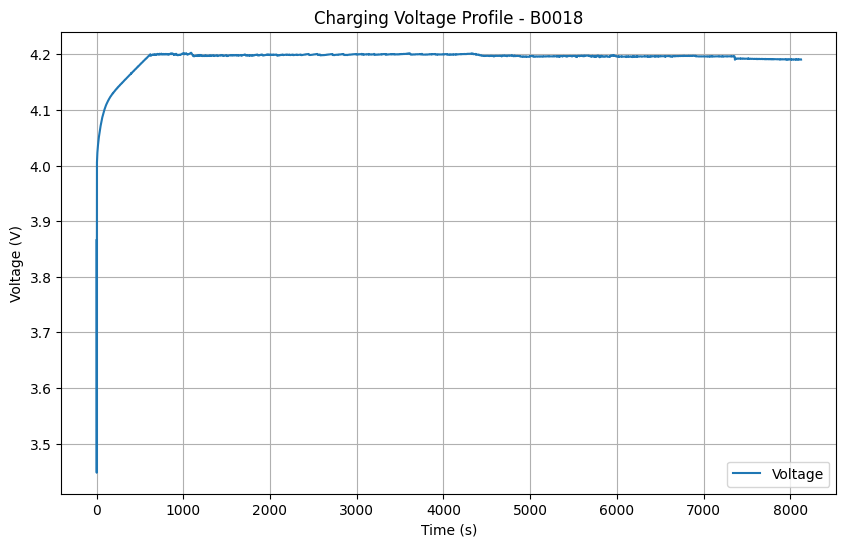

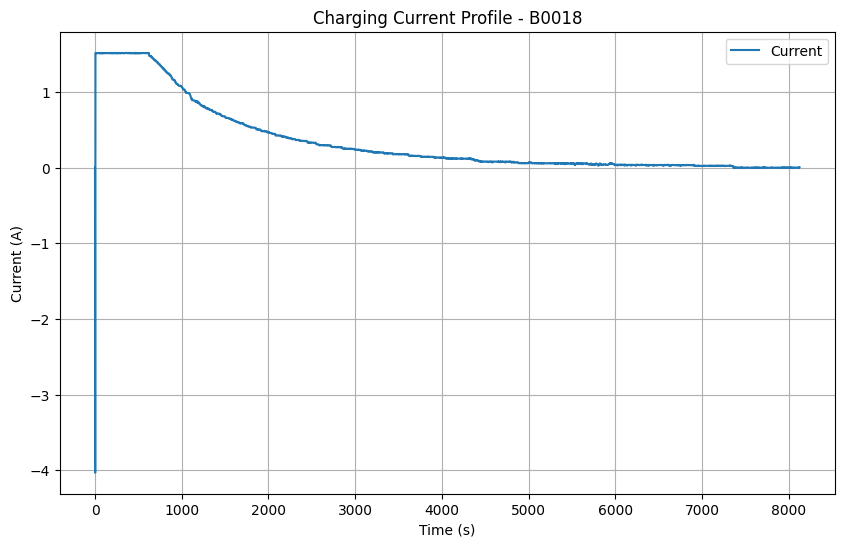

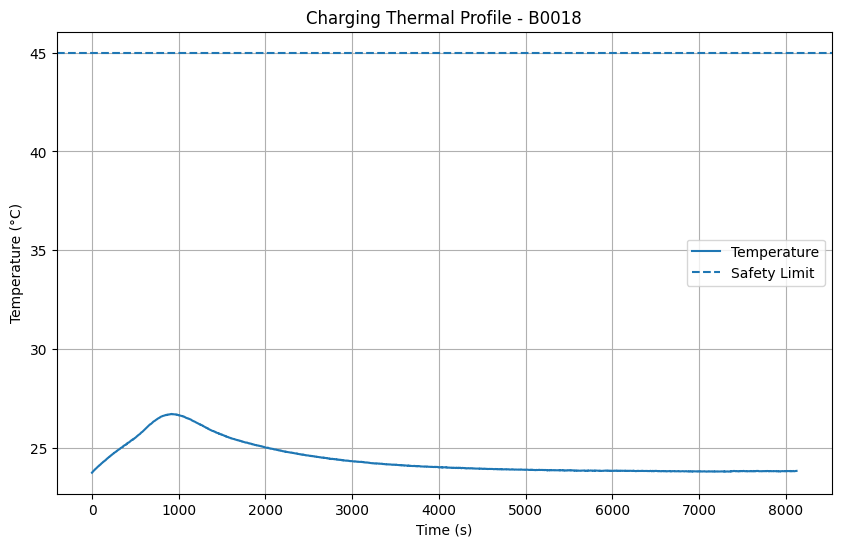


FINAL BMS PROJECT COMPLETED
SOC: Coulomb counting
SOH: Capacity-based calculation
ML: 5-model comparison
Thermal: Temperature monitoring
Voltage: Safety monitoring
Training: B0005 + B0006
Unseen test: B0018
Results saved successfully.


In [3]:
# ============================================================
# DATA-DRIVEN BATTERY MANAGEMENT SYSTEM
# NASA Li-ion Battery Dataset
#
# B0005 + B0006 -> Training
# B0018          -> Unseen Test
#
# SOC -> Coulomb Counting from charge profiles
# SOH -> Capacity-based calculation + ML prediction
# ============================================================


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor


# ============================================================
# 1. FILE CONFIGURATION
# ============================================================

TRAIN_BATTERIES = [
    "B0005",
    "B0006"
]

TEST_BATTERY = "B0018"


# Change these paths according to your folders

CHARGE_PATH = {
    "B0005": "B0005_charge.csv",
    "B0006": "B0006_charge.csv",
    "B0018": "B0018_charge.csv"
}


DISCHARGE_PATH = {
    "B0005": "B0005_discharge.csv",
    "B0006": "B0006_discharge.csv",
    "B0018": "B0018_discharge.csv"
}


# Approximate nominal capacity

NOMINAL_CAPACITY = 2.0


# BMS safety limits

MIN_VOLTAGE = 2.7
MAX_VOLTAGE = 4.2

MAX_TEMPERATURE = 45.0

LOW_SOC = 20.0
CRITICAL_SOC = 10.0


# ============================================================
# 2. LOAD DISCHARGE DATA
# ============================================================

def load_discharge_data(battery):

    print(
        f"\nLoading discharge data: {battery}"
    )

    df = pd.read_csv(
        DISCHARGE_PATH[battery]
    )

    df["Battery"] = battery

    return df


train_discharge = pd.concat(

    [
        load_discharge_data(battery)
        for battery in TRAIN_BATTERIES
    ],

    ignore_index=True

)


test_discharge = load_discharge_data(
    TEST_BATTERY
)


print("\n========================================")
print("DISCHARGE DATA")
print("========================================")

print(
    "Training rows:",
    len(train_discharge)
)

print(
    "Test rows:",
    len(test_discharge)
)


# ============================================================
# 3. CLEAN DISCHARGE DATA
# ============================================================

required_discharge = [

    "cycle",
    "voltage_battery",
    "current_battery",
    "temp_battery",
    "current_load",
    "voltage_load",
    "time",
    "capacity"

]


train_discharge = train_discharge.dropna(
    subset=required_discharge
)

test_discharge = test_discharge.dropna(
    subset=required_discharge
)


train_discharge = train_discharge.replace(
    [np.inf, -np.inf],
    np.nan
).dropna()


test_discharge = test_discharge.replace(
    [np.inf, -np.inf],
    np.nan
).dropna()


# ============================================================
# 4. CALCULATE SOH
# ============================================================

train_discharge["SOH"] = (

    train_discharge["capacity"]
    /
    NOMINAL_CAPACITY

) * 100


test_discharge["SOH"] = (

    test_discharge["capacity"]
    /
    NOMINAL_CAPACITY

) * 100


train_discharge["SOH"] = train_discharge[
    "SOH"
].clip(0, 100)


test_discharge["SOH"] = test_discharge[
    "SOH"
].clip(0, 100)


# ============================================================
# 5. CYCLE-LEVEL SOH DATA
# ============================================================

# Capacity is repeated across measurements belonging
# to the same discharge cycle.
#
# Therefore we create one representative row per cycle.

train_cycle = (

    train_discharge

    .groupby(
        ["Battery", "cycle"],
        as_index=False
    )

    .agg({

        "voltage_battery": "mean",

        "current_battery": "mean",

        "temp_battery": "mean",

        "current_load": "mean",

        "voltage_load": "mean",

        "time": "max",

        "capacity": "first",

        "SOH": "first"

    })

)


test_cycle = (

    test_discharge

    .groupby(
        ["Battery", "cycle"],
        as_index=False
    )

    .agg({

        "voltage_battery": "mean",

        "current_battery": "mean",

        "temp_battery": "mean",

        "current_load": "mean",

        "voltage_load": "mean",

        "time": "max",

        "capacity": "first",

        "SOH": "first"

    })

)


# ============================================================
# 6. FEATURE ENGINEERING
# ============================================================

def engineer_features(df):

    df = df.copy()


    # Current magnitude

    df["abs_current"] = np.abs(
        df["current_battery"]
    )


    # Battery electrical power

    df["battery_power"] = (

        np.abs(
            df["voltage_battery"]
            *
            df["current_battery"]
        )

    )


    # Load power

    df["load_power"] = (

        np.abs(
            df["voltage_load"]
            *
            df["current_load"]
        )

    )


    # Temperature rise

    df["temperature_rise"] = (

        df["temp_battery"]
        -
        df["temp_battery"].mean()

    )


    # Battery-load voltage difference

    df["voltage_difference"] = (

        df["voltage_battery"]
        -
        df["voltage_load"]

    )


    # Current difference

    df["current_difference"] = (

        np.abs(

            df["current_battery"]
            -
            df["current_load"]

        )

    )


    # Discharge duration

    df["duration_minutes"] = (

        df["time"]
        /
        60.0

    )


    # Approximate voltage/current resistance proxy

    df["resistance_proxy"] = (

        np.abs(
            df["voltage_difference"]
        )
        /
        np.maximum(
            df["abs_current"],
            0.001
        )

    )


    return df


train_cycle = engineer_features(
    train_cycle
)

test_cycle = engineer_features(
    test_cycle
)


# ============================================================
# 7. MODEL FEATURES
# ============================================================

features = [

    "cycle",

    "voltage_battery",

    "current_battery",

    "temp_battery",

    "current_load",

    "voltage_load",

    "time",

    "abs_current",

    "battery_power",

    "load_power",

    "temperature_rise",

    "voltage_difference",

    "current_difference",

    "duration_minutes",

    "resistance_proxy"

]


X_train = train_cycle[
    features
]

y_train = train_cycle[
    "SOH"
]


X_test = test_cycle[
    features
]

y_test = test_cycle[
    "SOH"
]


# ============================================================
# 8. DEFINE FIVE MODELS
# ============================================================

models = {


    # --------------------------------------------------------
    # 1. LINEAR REGRESSION
    # --------------------------------------------------------

    "Linear Regression":

        Pipeline([

            (
                "scaler",
                StandardScaler()
            ),

            (
                "model",
                LinearRegression()
            )

        ]),


    # --------------------------------------------------------
    # 2. RANDOM FOREST
    # --------------------------------------------------------

    "Random Forest":

        RandomForestRegressor(

            n_estimators=300,

            max_depth=12,

            min_samples_leaf=2,

            random_state=42,

            n_jobs=-1

        ),


    # --------------------------------------------------------
    # 3. SVR
    # --------------------------------------------------------

    "SVR":

        Pipeline([

            (
                "scaler",
                StandardScaler()
            ),

            (
                "model",

                SVR(

                    kernel="rbf",

                    C=100,

                    gamma="scale",

                    epsilon=0.1

                )

            )

        ]),


    # --------------------------------------------------------
    # 4. XGBOOST
    # --------------------------------------------------------

    "XGBoost":

        XGBRegressor(

            n_estimators=300,

            max_depth=5,

            learning_rate=0.05,

            subsample=0.8,

            colsample_bytree=0.8,

            objective="reg:squarederror",

            random_state=42,

            n_jobs=-1

        ),


    # --------------------------------------------------------
    # 5. MLP NEURAL NETWORK
    # --------------------------------------------------------

    "MLP Neural Network":

        Pipeline([

            (
                "scaler",
                StandardScaler()
            ),

            (
                "model",

                MLPRegressor(

                    hidden_layer_sizes=(
                        128,
                        64,
                        32
                    ),

                    activation="relu",

                    solver="adam",

                    learning_rate_init=0.001,

                    max_iter=1500,

                    early_stopping=True,

                    validation_fraction=0.15,

                    random_state=42

                )

            )

        ])

}


# ============================================================
# 9. TRAIN MODELS
# ============================================================

results = []

predictions = {}


print("\n========================================")
print("SOH MODEL COMPARISON")
print("========================================")


for name, model in models.items():

    print(
        f"\nTraining {name}..."
    )


    model.fit(

        X_train,

        y_train

    )


    prediction = model.predict(
        X_test
    )


    predictions[name] = prediction


    mae = mean_absolute_error(

        y_test,

        prediction

    )


    rmse = np.sqrt(

        mean_squared_error(

            y_test,

            prediction

        )

    )


    r2 = r2_score(

        y_test,

        prediction

    )


    results.append({

        "Model": name,

        "MAE (%)": mae,

        "RMSE (%)": rmse,

        "R2": r2

    })


# ============================================================
# 10. MODEL COMPARISON
# ============================================================

results_df = pd.DataFrame(
    results
)


results_df = results_df.sort_values(
    by="RMSE (%)"
)


print("\n========================================")
print("FINAL MODEL COMPARISON")
print("========================================")

print(

    results_df.to_string(
        index=False
    )

)


best = results_df.iloc[0]


print("\n========================================")
print("BEST MODEL")
print("========================================")

print(
    "Model:",
    best["Model"]
)

print(
    "MAE:",
    round(
        best["MAE (%)"],
        3
    ),
    "%"
)

print(
    "RMSE:",
    round(
        best["RMSE (%)"],
        3
    ),
    "%"
)

print(
    "R²:",
    round(
        best["R2"],
        4
    )
)


# ============================================================
# 11. SOH PREDICTION PLOT
# ============================================================

plt.figure(
    figsize=(12, 6)
)


plt.plot(

    test_cycle["cycle"],

    y_test,

    label="Actual SOH",

    linewidth=3

)


for name, prediction in predictions.items():

    plt.plot(

        test_cycle["cycle"],

        prediction,

        linestyle="--",

        label=name

    )


plt.xlabel(
    "Discharge Cycle"
)

plt.ylabel(
    "SOH (%)"
)

plt.title(
    "SOH Prediction Comparison - B0018"
)

plt.legend()

plt.grid()

plt.show()


# ============================================================
# 12. METRIC COMPARISON
# ============================================================

plt.figure(
    figsize=(11, 6)
)


plt.bar(

    results_df["Model"],

    results_df["MAE (%)"]

)


plt.ylabel(
    "MAE (%)"
)

plt.title(
    "Model Comparison - MAE"
)

plt.xticks(
    rotation=25
)

plt.grid(
    axis="y"
)

plt.show()


plt.figure(
    figsize=(11, 6)
)


plt.bar(

    results_df["Model"],

    results_df["RMSE (%)"]

)


plt.ylabel(
    "RMSE (%)"
)

plt.title(
    "Model Comparison - RMSE"
)

plt.xticks(
    rotation=25
)

plt.grid(
    axis="y"
)

plt.show()


plt.figure(
    figsize=(11, 6)
)


plt.bar(

    results_df["Model"],

    results_df["R2"]

)


plt.ylabel(
    "R²"
)

plt.title(
    "Model Comparison - R²"

)

plt.xticks(
    rotation=25
)

plt.grid(
    axis="y"
)

plt.show()


# ============================================================
# 13. CAPACITY DEGRADATION
# ============================================================

plt.figure(
    figsize=(10, 6)
)


for battery in TRAIN_BATTERIES:

    df = train_cycle[
        train_cycle["Battery"] == battery
    ]

    plt.plot(

        df["cycle"],

        df["capacity"],

        label=battery

    )


plt.plot(

    test_cycle["cycle"],

    test_cycle["capacity"],

    label=TEST_BATTERY

)


plt.xlabel(
    "Discharge Cycle"
)

plt.ylabel(
    "Capacity (Ah)"
)

plt.title(
    "Battery Capacity Degradation"
)

plt.legend()

plt.grid()

plt.show()


# ============================================================
# 14. TEMPERATURE MONITORING
# ============================================================

plt.figure(
    figsize=(10, 6)
)


plt.plot(

    test_cycle["cycle"],

    test_cycle["temp_battery"],

    label="Temperature"

)


plt.axhline(

    MAX_TEMPERATURE,

    linestyle="--",

    label="Safety Limit"

)


plt.xlabel(
    "Discharge Cycle"
)

plt.ylabel(
    "Temperature (°C)"
)

plt.title(
    "Battery Thermal Monitoring - B0018"
)

plt.legend()

plt.grid()

plt.show()


# ============================================================
# 15. VOLTAGE MONITORING
# ============================================================

plt.figure(
    figsize=(10, 6)
)


plt.plot(

    test_cycle["cycle"],

    test_cycle["voltage_battery"],

    label="Battery Voltage"

)


plt.axhline(

    MIN_VOLTAGE,

    linestyle="--",

    label="Minimum Limit"

)


plt.axhline(

    MAX_VOLTAGE,

    linestyle="--",

    label="Maximum Limit"

)


plt.xlabel(
    "Discharge Cycle"
)

plt.ylabel(
    "Voltage (V)"
)

plt.title(
    "Battery Voltage Monitoring - B0018"
)

plt.legend()

plt.grid()

plt.show()


# ============================================================
# SOC ESTIMATION FOR MULTIPLE CHARGE/DISCHARGE CYCLES
# ============================================================

def calculate_soc_coulomb_counting(
    df,
    capacity_ah,
    initial_soc=100
):
    """
    Estimate SOC using Coulomb counting.

    SOC(t) = SOC(t0) - integral(I dt) / Q

    Assumes positive current represents battery discharge.
    """

    df = df.sort_values("time").copy()

    current = np.abs(
        df["current_battery"].values
    )

    time = df["time"].values

    soc = np.zeros(len(df))

    soc[0] = initial_soc

    for i in range(1, len(df)):

        dt = time[i] - time[i - 1]

        if dt < 0:
            dt = 0

        delta_soc = (
            current[i] * dt
            / (capacity_ah * 3600)
        ) * 100

        soc[i] = soc[i - 1] - delta_soc

        soc[i] = np.clip(
            soc[i],
            0,
            100
        )

    df["SOC"] = soc

    return df


# ============================================================
# SELECT MULTIPLE B0018 CHARGE CYCLES
# ============================================================

soc_battery = "B0018"

charge_data = charge_test[
    charge_test["Battery"] == soc_battery
].copy()


available_cycles = sorted(
    charge_data["cycle"].unique()
)


print("\n========================================")
print("AVAILABLE CHARGE CYCLES")
print("========================================")

print(
    "Number of charge cycles:",
    len(available_cycles)
)

print(
    "First cycle:",
    available_cycles[0]
)

print(
    "Last cycle:",
    available_cycles[-1]
)


# ------------------------------------------------------------
# Select cycles automatically
# ------------------------------------------------------------

number_of_cycles = 6

selected_cycles = np.linspace(
    available_cycles[0],
    available_cycles[-1],
    number_of_cycles,
    dtype=int
)


# Make sure selected values actually exist
selected_cycles = [

    cycle

    for cycle in selected_cycles

    if cycle in available_cycles

]


print(
    "Selected cycles:",
    selected_cycles
)


# ============================================================
# CALCULATE SOC FOR EACH SELECTED CYCLE
# ============================================================

soc_results = {}


for cycle_number in selected_cycles:

    cycle_data = charge_data[
        charge_data["cycle"] == cycle_number
    ].copy()


    cycle_data = cycle_data.sort_values(
        "time"
    )


    if len(cycle_data) < 2:

        continue


    # Use nominal capacity
    # for Coulomb counting

    capacity_ah = NOMINAL_CAPACITY


    cycle_soc = calculate_soc_coulomb_counting(

        cycle_data,

        capacity_ah,

        initial_soc=100

    )


    soc_results[
        cycle_number
    ] = cycle_soc


# ============================================================
# PLOT SOC FOR MULTIPLE CYCLES
# ============================================================

plt.figure(
    figsize=(12, 7)
)


for cycle_number, df in soc_results.items():

    plt.plot(

        df["time"] / 60,

        df["SOC"],

        label=f"Cycle {cycle_number}"

    )


plt.axhline(

    LOW_SOC,

    linestyle="--",

    label="Low SOC (20%)"

)


plt.axhline(

    CRITICAL_SOC,

    linestyle="--",

    label="Critical SOC (10%)"

)


plt.xlabel(
    "Time (min)"
)

plt.ylabel(
    "SOC (%)"
)

plt.title(

    "SOC Estimation Across Multiple B0018 Cycles"

)

plt.legend()

plt.grid()

plt.show()


# ============================================================
# SOC SUMMARY
# ============================================================

print("\n========================================")
print("SOC SUMMARY")
print("========================================")

for cycle_number, df in soc_results.items():

    print(

        f"Cycle {cycle_number}: "

        f"Initial SOC = "
        f"{df['SOC'].iloc[0]:.2f}% | "

        f"Final SOC = "
        f"{df['SOC'].iloc[-1]:.2f}%"

    )

# ============================================================
# 21. BMS SAFETY STATUS
# ============================================================

def get_bms_status(row):

    if row["temp_battery"] > MAX_TEMPERATURE:

        return "OVER TEMPERATURE"


    if row["voltage_battery"] < MIN_VOLTAGE:

        return "UNDER VOLTAGE"


    if row["voltage_battery"] > MAX_VOLTAGE:

        return "OVER VOLTAGE"


    if row["SOC"] <= CRITICAL_SOC:

        return "CRITICAL SOC"


    if row["SOC"] <= LOW_SOC:

        return "LOW SOC"


    return "NORMAL"


cycle_soc[
    "BMS_Status"
] = cycle_soc.apply(

    get_bms_status,

    axis=1

)


print("\n========================================")
print("BMS STATUS SUMMARY")
print("========================================")

print(
    cycle_soc[
        "BMS_Status"
    ].value_counts()
)


# ============================================================
# 22. CHARGE DATA ANALYSIS
# ============================================================

def load_charge_data(battery):

    print(
        f"\nLoading charge data: {battery}"
    )

    df = pd.read_csv(
        CHARGE_PATH[battery]
    )

    df["Battery"] = battery

    return df


# Load only B0018 charge data for visualization
# to avoid unnecessarily loading all large files.

charge_test = load_charge_data(
    TEST_BATTERY
)


charge_test = charge_test.dropna(
    subset=[

        "cycle",

        "voltage_battery",

        "current_battery",

        "temp_battery",

        "time"

    ]
)


# ============================================================
# 23. CHARGE PROFILE
# ============================================================

# Select first charge cycle

charge_cycle_number = (
    charge_test["cycle"].iloc[0]
)


charge_cycle = charge_test[
    charge_test["cycle"]
    ==
    charge_cycle_number
].copy()


charge_cycle = charge_cycle.sort_values(
    "time"
)


print("\n========================================")
print("CHARGE PROFILE")
print("========================================")

print(
    "Battery:",
    TEST_BATTERY
)

print(
    "Charge cycle:",
    charge_cycle_number
)

print(
    "Measurements:",
    len(charge_cycle)
)


# ============================================================
# 24. CHARGE VOLTAGE
# ============================================================

plt.figure(
    figsize=(10, 6)
)


plt.plot(

    charge_cycle["time"],

    charge_cycle["voltage_battery"],

    label="Voltage"

)


plt.xlabel(
    "Time (s)"
)

plt.ylabel(
    "Voltage (V)"
)

plt.title(
    f"Charging Voltage Profile - "
    f"{TEST_BATTERY}"
)

plt.legend()

plt.grid()

plt.show()


# ============================================================
# 25. CHARGE CURRENT
# ============================================================

plt.figure(
    figsize=(10, 6)
)


plt.plot(

    charge_cycle["time"],

    charge_cycle["current_battery"],

    label="Current"

)


plt.xlabel(
    "Time (s)"
)

plt.ylabel(
    "Current (A)"
)

plt.title(
    f"Charging Current Profile - "
    f"{TEST_BATTERY}"
)

plt.legend()

plt.grid()

plt.show()


# ============================================================
# 26. CHARGE TEMPERATURE
# ============================================================

plt.figure(
    figsize=(10, 6)
)


plt.plot(

    charge_cycle["time"],

    charge_cycle["temp_battery"],

    label="Temperature"

)


plt.axhline(

    MAX_TEMPERATURE,

    linestyle="--",

    label="Safety Limit"

)


plt.xlabel(
    "Time (s)"
)

plt.ylabel(
    "Temperature (°C)"
)

plt.title(
    f"Charging Thermal Profile - "
    f"{TEST_BATTERY}"
)

plt.legend()

plt.grid()

plt.show()


# ============================================================
# 27. SAVE RESULTS
# ============================================================

results_df.to_csv(

    "BMS_model_comparison.csv",

    index=False

)


train_cycle.to_csv(

    "BMS_training_cycle_features.csv",

    index=False

)


test_cycle.to_csv(

    "BMS_B0018_SOH_predictions.csv",

    index=False

)


cycle_soc.to_csv(

    "BMS_B0018_SOC_results.csv",

    index=False

)


print("\n========================================")
print("FINAL BMS PROJECT COMPLETED")
print("========================================")

print(
    "SOC: Coulomb counting"
)

print(
    "SOH: Capacity-based calculation"
)

print(
    "ML: 5-model comparison"
)

print(
    "Thermal: Temperature monitoring"
)

print(
    "Voltage: Safety monitoring"
)

print(
    "Training: B0005 + B0006"
)

print(
    "Unseen test: B0018"
)

print(
    "Results saved successfully."
)